# Del clima a la generación real: plantas solares de Colombia

Pregunta: ¿cuánto de la variación diaria de la generación de una planta solar colombiana se explica con el clima de ese día?

El cuaderno baja la generación real desde XM, la empareja con las plantas del dataset de Mantilla-Guerra et al. (2026), trae el clima
de cada sitio y compara varios modelos. Las referencias están al final y en `referencias.bib`.

No usamos `solar_aptitude` porque el índice del dataset sale solo de pendiente, orientación, sombra y curvatura (Ec. 1 del paper), así que
el clima no puede predecirlo. El factor de capacidad real sí depende del clima por física, y eso se puede medir.

## De XM y Open-Meteo a la base diaria

![Esquema de la base de Colombia](fig_pipeline_clima.png)

## 1. Fuentes y corte de tiempo

| Fuente | Qué aporta | Notas |
|---|---|---|
| XM, API pública `servapibi.xm.com.co` (XM, 2026) | Generación horaria por planta (`Gene`), capacidad efectiva neta diaria (`CapEfecNeta`) | La API no pide clave. No revisamos la licencia de los datos |
| Dataset del paper, con la tabla de GEM de febrero de 2026 (Mantilla-Guerra et al., 2026; GEM, 2026) | Coordenadas, nombre y capacidad de cada planta | Se cita la versión de la revista; el preprint está en arXiv |
| Open-Meteo, API histórica (Zippenfenig, 2023) | Radiación, nubosidad, temperatura, humedad, viento y radiación en plano inclinado, por hora | Según la documentación, el modelo por defecto combina IFS HRES, ERA5 y ERA5-Land (Hersbach et al., 2020; Muñoz-Sabater et al., 2021) |

Corte de tiempo: el paper usa la versión de GEM de febrero de 2026, el potencial de Global Solar Atlas del período 2018-2024 y carreteras de
OSM del 14 de marzo de 2026. No dice qué años promedia ERA5. La ventana de este cuaderno termina el 28 de febrero de 2026, el mes de esa versión
de GEM, y empieza el 1 de enero de 2024. El inicio es decisión nuestra.

El clima no es una medición en el sitio. Open-Meteo entrega el valor de la celda de un modelo. Comparamos dos productos con la misma consulta:
`era5`, de 0.25° y documentado en la literatura, y `best_match`, el valor por defecto, que en las pruebas cayó en una celda más fina (ver sección 6).

In [1]:
import json, re, time, unicodedata, difflib, warnings
from datetime import date, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import requests
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
from scipy.stats import spearmanr, wilcoxon
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import LeaveOneGroupOut

warnings.filterwarnings("ignore")

SEED = 42
RNG = np.random.default_rng(SEED)
START, END = date(2024, 1, 1), date(2026, 2, 28)
CAP_REF_DATE = "2026-02-15"      # fecha para decidir qué plantas pasan de 1 MW
MIN_MW = 1.0
RAMP_DAYS = 60                   # días de puesta en marcha que se excluyen en el análisis principal
MIN_DIAS = 100                   # una planta con menos días útiles que esto no entra a la evaluación
CLUSTER_KM = 100                 # plantas a menos de esta distancia comparten clima y se tratan como un grupo
XM_URL = "https://servapibi.xm.com.co/"
OM_URL = "https://archive-api.open-meteo.com/v1/archive"
DATA = Path("datos_xm")
DATA.mkdir(exist_ok=True)
GEM_CSV = Path("..") / "Dataset_Mundial_Final(2).csv"

## 2. Generación real desde XM

La API acepta rangos de hasta 30 días en datos horarios y diarios. Cada descarga se guarda en `datos_xm/` y, si el archivo ya existe, no se
vuelve a pedir.

Primero se listan los recursos de XM con fuente solar. Nos quedamos con los que tenían al menos 1 MW de capacidad efectiva neta en la fecha
de referencia. Los autogeneradores pequeños (`AGPE`) quedan fuera por tamaño.

In [2]:
def xm_post(endpoint, body, tries=3):
    for _ in range(tries):
        try:
            r = requests.post(XM_URL + endpoint, json=body, timeout=180)
            if r.ok:
                return r.json()
        except requests.RequestException:
            pass
        time.sleep(2)
    raise RuntimeError(f"XM no respondió para {endpoint} {body.get('MetricId')}")

path_rec = DATA / "recursos_solares.csv"
if path_rec.exists():
    solares = pd.read_csv(path_rec)
else:
    lista = xm_post("lists", {"MetricId": "ListadoRecursos"})
    todos = pd.DataFrame([it["ListEntities"][0]["Values"] for it in lista["Items"]])
    es_solar = todos.EnerSource.str.contains("RAD|SOL", na=False) | todos.Type.str.contains("SOLAR", case=False, na=False)
    solares = todos[es_solar].copy()
    solares.to_csv(path_rec, index=False)

print(f"Recursos solares registrados en XM: {len(solares)}")
print("Autogeneradores o generación distribuida (AGPE, GD):", int(solares.Name.str.match(r"^(AGPE|GD) ").sum()))

Recursos solares registrados en XM: 2213
Autogeneradores o generación distribuida (AGPE, GD): 2020


In [3]:
def capacidad(ini, fin, codigos):
    j = xm_post("daily", {"MetricId": "CapEfecNeta", "StartDate": str(ini), "EndDate": str(fin),
                          "Entity": "Recurso", "Filter": codigos})
    return [{"date": it["Date"], "code": e["Code"], "cap_MW": float(e["Value"]) / 1000}   # la API entrega kW
            for it in j["Items"] for e in it["DailyEntities"] if e.get("Value") not in (None, "")]

ref = pd.DataFrame(capacidad(CAP_REF_DATE, CAP_REF_DATE, solares.Code.tolist()))
codigos = sorted(ref[ref.cap_MW >= MIN_MW].code)
print(f"Plantas con al menos {MIN_MW} MW al {CAP_REF_DATE}: {len(codigos)}")

Plantas con al menos 1.0 MW al 2026-02-15: 28


In [4]:
def descarga_por_tramos(ruta, pedir):
    if ruta.exists():
        return pd.read_csv(ruta)
    filas, ini = [], START
    while ini <= END:
        fin = min(ini + timedelta(days=29), END)
        filas.extend(pedir(ini, fin))
        ini = fin + timedelta(days=1)
    df = pd.DataFrame(filas)
    df.to_csv(ruta, index=False)
    return df

def pedir_generacion(ini, fin):
    j = xm_post("hourly", {"MetricId": "Gene", "StartDate": str(ini), "EndDate": str(fin),
                           "Entity": "Recurso", "Filter": codigos})
    return [{"date": it["Date"], **ent["Values"]} for it in j["Items"] for ent in it["HourlyEntities"]]

gen = descarga_por_tramos(DATA / "generacion_horaria.csv", pedir_generacion)
cap_dia = descarga_por_tramos(DATA / "capacidad_diaria.csv", lambda a, b: capacidad(a, b, codigos))

horas = [c for c in gen.columns if c.startswith("Hour")]
gen[horas] = gen[horas].apply(pd.to_numeric, errors="coerce")
gen["date"] = pd.to_datetime(gen["date"])
gen["kwh"] = gen[horas].sum(axis=1)
cap_dia["date"] = pd.to_datetime(cap_dia["date"])
print("Generación:", gen.shape, "| capacidad diaria:", cap_dia.shape, "| plantas:", gen.code.nunique())

Generación: (15326, 27) | capacidad diaria: (11170, 3) | plantas: 27


## 3. Factor de capacidad diario

El factor de capacidad (FC) es la energía del día dividida entre la que habría entregado la planta a potencia nominal las 24 horas:

`FC = kWh del día / (capacidad efectiva neta en kW × 24)`

La capacidad es la de ese mismo día, porque varias plantas crecen por etapas. Con la capacidad de un día fijo del mes (el 15),
el nivel de algunas plantas se movía por el denominador. Un FC mayor a 1.05 se descarta como dato roto.

Puesta en marcha: en una planta cuyo primer día con generación cae dentro de la ventana, los primeros `RAMP_DAYS` días se excluyen del análisis
principal. El criterio no mira ni la radiación ni el FC. Una planta que ya operaba el 1 de enero de 2024 no tiene su arranque observado y no pierde días.

In [5]:
diario = gen[["code", "date", "kwh"]].merge(cap_dia, on=["code", "date"], how="inner")
diario["fc"] = diario.kwh / 1000 / (diario.cap_MW * 24)
diario = diario[(diario.kwh > 0) & (diario.cap_MW > 0)].copy()

primer = diario.groupby("code").date.min().rename("primer_dia")
diario = diario.merge(primer, on="code")
arranque_observado = diario.primer_dia > pd.Timestamp(START) + pd.Timedelta(days=7)
diario["dias_desde_arranque"] = np.where(arranque_observado, (diario.date - diario.primer_dia).dt.days, 10_000)

print("Filas planta-día con generación y capacidad:", len(diario))
print("Días con FC mayor a 1.05:", int((diario.fc > 1.05).sum()), "(se descartan)")
diario = diario[diario.fc <= 1.05]
print("Plantas con arranque observado dentro de la ventana:", int(diario.groupby("code").dias_desde_arranque.min().lt(10_000).sum()))

resumen = (diario.groupby("code")
           .agg(primer_dia=("date", "min"), dias=("date", "nunique"), cap_MW=("cap_MW", "median"), fc_medio=("fc", "mean"))
           .reset_index()
           .merge(solares[["Code", "Name"]], left_on="code", right_on="Code").drop(columns="Code"))
resumen.sort_values("cap_MW", ascending=False).round(3)

Filas planta-día con generación y capacidad: 10563
Días con FC mayor a 1.05: 0 (se descartan)
Plantas con arranque observado dentro de la ventana: 25


,code,primer_dia,dias,cap_MW,fc_medio,Name
24,GYPO,2024-11-30,450,370.00,0.225,GUAYEPO
19,4YCF,2025-10-23,129,160.00,0.243,SHANGRI LA
0,3DDT,2024-06-24,609,150.00,0.227,LATAM SOLAR LA LOMA
6,3IRX,2024-03-08,699,102.00,0.231,PORTON DEL SOL
3,3HF5,2024-06-22,617,100.00,0.277,FUNDACION
7,3IZ6,2024-06-19,620,100.00,0.254,PARQUE SOLAR LA UNION
26,TPUY,2024-06-12,627,83.00,0.281,PARQUE SOLAR TEPUY
25,MATA,2024-06-27,612,80.00,0.252,LA MATA
23,EPFV,2024-03-23,707,68.00,0.293,EL PASO
4,3INX,2024-12-22,433,50.00,0.226,CARACOLI I


## 4. Emparejar con el dataset por nombre y capacidad

XM no entrega coordenadas y el clima las necesita. El dataset del paper sí las trae para algunas plantas. Primero se calculan los tres candidatos más parecidos de cada
planta en ese dataset. Luego se deja una tabla de decisiones hechas a mano, con el motivo de cada una. Siete plantas no aparecen en el dataset con un nombre reconocible,
y para ellas se usa la ficha pública de GEM, que es la misma fuente de la que sale el dataset. Cada una se contrastó con prensa o con el desarrollador.

Se acepta un emparejamiento cuando el nombre normalizado coincide de forma clara y la capacidad es igual o muy parecida (dos casos tienen capacidad distinta y quedan anotados).
Si hay dos filas de GEM con el mismo nombre, se verifica con una fuente externa cuál corresponde a la planta que genera. Si el nombre se parece pero la capacidad o el lugar no
encajan, se descarta, y lo mismo si las coordenadas de la fuente contradicen el lugar que dice la propia ficha.

In [6]:
gem = pd.read_csv(GEM_CSV, sep=";", decimal=",", encoding="utf-8-sig")
col = gem[gem.country.eq("Colombia")].reset_index(drop=True)

PALABRAS = r"\b(agpe|gd|autog|planta|parque|solar|solares|fv|fotovoltaic[oa]|photovoltaic|power|plant|farm|project|pv|park|colombia|de|del|la|el|los|las|i|ii|iii|iv|v|vi)\b"
def normaliza(s):
    s = unicodedata.normalize("NFKD", str(s)).encode("ascii", "ignore").decode().lower()
    s = re.sub(r"\(.*?\)", " ", s)
    s = re.sub(PALABRAS, " ", s)
    return " ".join(re.sub(r"[^a-z0-9 ]", " ", s).split())

col["nombre_norm"] = col.plant_name.map(normaliza)
xm = resumen[["code", "Name", "cap_MW"]].copy()

def candidatos(nombre, k=3):
    clave = normaliza(nombre)
    sim = col.nombre_norm.map(lambda t: difflib.SequenceMatcher(None, clave, t).ratio())
    return col.assign(similitud=sim).sort_values("similitud", ascending=False).head(k)

filas = []
for _, r in xm.iterrows():
    for _, c in candidatos(r.Name).iterrows():
        filas.append({"code": r.code, "xm": r.Name, "xm_MW": round(r.cap_MW, 1), "gem": c.plant_name,
                      "gem_MW": c.capacity, "gem_estado": c.operational_status, "similitud": round(c.similitud, 2)})
pd.DataFrame(filas).head(30)

,code,xm,xm_MW,gem,gem_MW,gem_estado,similitud
0,3DDT,LATAM SOLAR LA LOMA,150.0,Atalaya solar farm,99.9,pre-construction,0.59
1,3DDT,LATAM SOLAR LA LOMA,150.0,La Loma Solar Park,150.0,operating,0.57
2,3DDT,LATAM SOLAR LA LOMA,150.0,Altamira Solar Park,90.0,pre-construction,0.56
3,3EDL,BOSQUES SOLARES DE LOS LLANOS 5,17.9,Los Morrosquillos 3 solar farm,19.9,pre-construction,0.58
4,3EDL,BOSQUES SOLARES DE LOS LLANOS 5,17.9,Helios Lanceros solar farm,19.9,construction,0.52
5,3EDL,BOSQUES SOLARES DE LOS LLANOS 5,17.9,Autoconsumo Del Bloque Llanos 34 - Geopark sol...,9.9,operating,0.50
6,3EFY,BOSQUES SOLARES DE LOS LLANOS 4,19.9,Los Morrosquillos 3 solar farm,19.9,pre-construction,0.58
7,3EFY,BOSQUES SOLARES DE LOS LLANOS 4,19.9,Autoconsumo Del Bloque Llanos 34 - Geopark sol...,9.9,operating,0.54
8,3EFY,BOSQUES SOLARES DE LOS LLANOS 4,19.9,Helios Lanceros solar farm,19.9,construction,0.52
9,3HF5,FUNDACION,100.0,Fundación Solar Park,100.0,pre-construction,1.00


In [7]:
# Clave: código XM. Valor: (nombre exacto en GEM, motivo)
EMPAREJAMIENTOS = {
    "3DDT": ("La Loma Solar Park",             "150 MW en ambos. 'Latam Solar' es el desarrollador"),
    "3HF5": ("Fundacion (Latamsolar) solar farm", "100 MW en ambos. El parque Fundación de Enel está en Pivijay, Magdalena (pv magazine LATAM, 2023; Enel Green Power, 2023). "
                                                "El geocodificador de Open-Meteo ubica Pivijay en 10.462, -74.616, igual que esta fila de GEM. "
                                                "La otra fila, 'Fundación Solar Park' (10.518, -74.182), cae en el municipio de Fundación, 48 km al este, y se descarta"),
    "3INX": ("Caracolí Solar Plant",           "50 MW en ambos. GEM la marca pre-construcción pero XM la tiene generando"),
    "3J2B": ("Planeta Rica Solar Park",        "19.9 MW en ambos"),
    "4RGG": ("Baranoa (Cecropia) solar farm",  "19.9 MW en ambos. GEM la marca pre-construcción"),
    "5F43": ("Alma Solar PV solar farm",       "9.8 MW en ambos. Hay otra 'Alma solar farm' de 20 MW en otra ubicación. La ubicación de esta fila no se contrastó con una fuente externa y la planta tiene solo unos 60 días de datos"),
    "EPFV": ("El Paso PV Solar Park",          "68 MW en XM, 70 MW en GEM"),
    "GYPO": ("Guayepo PV Solar Park",          "370 MW en XM, 486.7 MW en GEM, que suma más etapas. Mismo sitio. XM registra Guayepo III como otro recurso de 200 MW"),
    "MATA": ("La Mata solar farm (Colombia)",  "80 MW en ambos"),
    "TPUY": ("Tepuy solar farm",               "83 MW en ambos"),
}

# Plantas que el dataset del paper no trae con ese nombre. Las coordenadas salen de la ficha pública de GEM,
# la misma fuente que alimenta el dataset. Cada una se contrastó con prensa o con el desarrollador.
GEM_WIKI = "https://www.gem.wiki/"
EXTRAS = {
    "3EFY": {"gem": "Los Llanos Solar Forest, fase 4", "lat": 4.2152, "lon": -72.0266, "precision": "aproximada (GEM)",
             "fuente": GEM_WIKI + "Los_Llanos_Solar_Forest",
             "motivo": "Puerto Gaitán, Meta. 19.9 MWac en GEM y en XM. Fases 4 y 5 inauguradas en julio de 2022 (pv magazine LATAM, 2022)"},
    "3EDL": {"gem": "Los Llanos Solar Forest, fase 5", "lat": 4.2108, "lon": -72.0310, "precision": "exacta (GEM)",
             "fuente": GEM_WIKI + "Los_Llanos_Solar_Forest",
             "motivo": "Puerto Gaitán, Meta. 17.9 MWac en GEM y en XM"},
    "3K8C": {"gem": "Bolívar PV Solar Forest, fase 503", "lat": 10.5732, "lon": -74.8904, "precision": "exacta (GEM)",
             "fuente": GEM_WIKI + "Bolivar_PV_Solar_Forest",
             "motivo": "Sabanalarga, Atlántico. BSB significa Bosques Solares de Bolívar, de ISAGEN, cinco plantas de 19.9 MW (pv magazine LATAM, 2024-07-29)"},
    "3K8E": {"gem": "Bolívar PV Solar Forest, fase 504", "lat": 10.5796, "lon": -74.8903, "precision": "exacta (GEM)",
             "fuente": GEM_WIKI + "Bolivar_PV_Solar_Forest",
             "motivo": "Sabanalarga, Atlántico. Está a unos 0.7 km de la fase 503. Que la fase 503 sea 3K8C y la 504 sea 3K8E se asume por la numeración, sin otra fuente"},
    "3IZ6": {"gem": "La Unión Solar Park (Colombia)", "lat": 8.6920, "lon": -75.7962, "precision": "exacta (GEM)",
             "fuente": GEM_WIKI + "La_Uni%C3%B3n_Solar_Park",
             "motivo": "Montería, Córdoba. Solarpack (hoy Zelestra). 99.9 MWac en GEM y 100 MW en XM. El código XM y la fecha de arranque no se contrastaron con una fuente externa"},
    "3IRX": {"gem": "Portón Del Sol PV Solar Park", "lat": 5.4104, "lon": -74.7141, "precision": "exacta (GEM)",
             "fuente": GEM_WIKI + "Port%C3%B3n_Del_Sol_PV_Solar_Park",
             "motivo": "La Dorada, Caldas. Enerfín. 102 MW en GEM y en XM. El Espectador dice que entró en operación comercial el 8 de marzo de 2024, la misma fecha de la primera generación en XM"},
    "3IQA": {"gem": "Sunnorte Solar Plant", "lat": 8.2247, "lon": -73.3233, "precision": "exacta (GEM)",
             "fuente": GEM_WIKI + "Sunnorte_Solar_Plant",
             "motivo": "Ocaña, Norte de Santander. Ecoener. 35 MWac en GEM y en XM. GEM y Ecoener dicen 2023, y XM muestra la primera generación en noviembre de 2024. La diferencia de fechas no se explicó"},
}
NO_EMPAREJADAS = {
    "3PWF": "Autogenerador de 4.99 MW. Una hipótesis (Celsia Solar Palmira 2) no se confirmó con ninguna fuente. Queda fuera",
    "4YCF": "Shangri-La, 160 MW. Departamento confirmado (Tolima) pero las coordenadas de GEM caen unos 230 km al este de Ibagué y contradicen su propia ficha. Tiene además pocos días de datos",
}

sin_emparejar = xm[~xm.code.isin(list(EMPAREJAMIENTOS) + list(EXTRAS))]
print(f"Emparejadas con el dataset: {len(EMPAREJAMIENTOS)} | con la ficha de GEM: {len(EXTRAS)} | de {len(xm)}")
print("Sin emparejar (sin coordenadas, quedan fuera por ahora):")
print(sin_emparejar.assign(cap_MW=lambda d: d.cap_MW.round(1)).to_string(index=False))

Emparejadas con el dataset: 10 | con la ficha de GEM: 7 | de 27
Sin emparejar (sin coordenadas, quedan fuera por ahora):
code                         Name  cap_MW
3PWF AUTOG SOLAR PALMIRA II BERRY     5.0
3PXC                      BSB 501    19.9
3PXE                      BSB 500    19.9
3PXF                      BSB 502    19.9
4VYM    AUTOG MOLINOS SANTA MARTA     3.3
4WUK                AUTOG COMOLSA     3.3
4WUM                   AUTOG QBCO     3.3
4YCF                   SHANGRI LA   160.0
4Z9Q             SOLAR ARDOBELA I     9.9
4Z9S            SOLAR ARDOBELA II     9.9


In [8]:
plantas = []
for code_xm, (nombre_gem, motivo) in EMPAREJAMIENTOS.items():
    g = col[col.plant_name == nombre_gem]
    assert len(g) == 1, f"{nombre_gem}: {len(g)} filas en GEM"
    g = g.iloc[0]
    plantas.append({"code": code_xm, "planta": xm.set_index("code").loc[code_xm, "Name"],
                    "lat": g.latitude, "lon": g.longitude, "cap_gem_MW": g.capacity, "estado_gem": g.operational_status})
for code_xm, e in EXTRAS.items():
    plantas.append({"code": code_xm, "planta": xm.set_index("code").loc[code_xm, "Name"],
                    "lat": e["lat"], "lon": e["lon"], "cap_gem_MW": np.nan, "estado_gem": "operating (ficha GEM)"})
plantas = pd.DataFrame(plantas)

# Grupos por cercanía: plantas a menos de CLUSTER_KM comparten clima y no son observaciones independientes
def haversine_km(a, b):
    la1, lo1, la2, lo2 = map(np.radians, [a[0], a[1], b[0], b[1]])
    h = np.sin((la2 - la1) / 2) ** 2 + np.cos(la1) * np.cos(la2) * np.sin((lo2 - lo1) / 2) ** 2
    return 2 * 6371 * np.arcsin(np.sqrt(h))

D = np.array([[haversine_km(a, b) for b in plantas[["lat", "lon"]].values] for a in plantas[["lat", "lon"]].values])
plantas["grupo"] = fcluster(linkage(squareform(D, checks=False), method="single"), CLUSTER_KM, criterion="distance")
print("Grupos de plantas a menos de", CLUSTER_KM, "km (enlace simple):", plantas.grupo.nunique())
plantas.round(3)

Grupos de plantas a menos de 100 km (enlace simple): 7


,code,planta,lat,lon,cap_gem_MW,estado_gem,grupo
0,3DDT,LATAM SOLAR LA LOMA,9.706,-73.522,150.0,operating,5
1,3HF5,FUNDACION,10.463,-74.616,100.0,operating,6
2,3INX,CARACOLI I,10.641,-75.002,50.0,pre-construction,6
3,3J2B,SOLAR PLANETA RICA,8.442,-75.603,19.9,operating,3
4,4RGG,PARQUE SOLAR BARANOA,10.793,-74.915,19.9,pre-construction,6
5,5F43,ALMA II,6.687,-71.276,9.8,operating,7
6,EPFV,EL PASO,9.781,-73.720,70.0,operating,5
7,GYPO,GUAYEPO,10.605,-74.783,486.7,operating,6
8,MATA,LA MATA,8.586,-73.613,80.0,operating,4
9,TPUY,PARQUE SOLAR TEPUY,5.469,-74.671,83.0,operating,1


In [9]:
pd.set_option("display.max_colwidth", 200)
display(pd.DataFrame(EXTRAS).T[["gem", "lat", "lon", "precision", "fuente", "motivo"]])
print("Plantas de XM investigadas y descartadas:")
for k, v in NO_EMPAREJADAS.items():
    print(f"  {k}: {v}")

,gem,lat,lon,precision,fuente,motivo
3EFY,"Los Llanos Solar Forest, fase 4",4.2152,-72.0266,aproximada (GEM),https://www.gem.wiki/Los_Llanos_Solar_Forest,"Puerto Gaitán, Meta. 19.9 MWac en GEM y en XM. Fases 4 y 5 inauguradas en julio de 2022 (pv magazine LATAM, 2022)"
3EDL,"Los Llanos Solar Forest, fase 5",4.2108,-72.031,exacta (GEM),https://www.gem.wiki/Los_Llanos_Solar_Forest,"Puerto Gaitán, Meta. 17.9 MWac en GEM y en XM"
3K8C,"Bolívar PV Solar Forest, fase 503",10.5732,-74.8904,exacta (GEM),https://www.gem.wiki/Bolivar_PV_Solar_Forest,"Sabanalarga, Atlántico. BSB significa Bosques Solares de Bolívar, de ISAGEN, cinco plantas de 19.9 MW (pv magazine LATAM, 2024-07-29)"
3K8E,"Bolívar PV Solar Forest, fase 504",10.5796,-74.8903,exacta (GEM),https://www.gem.wiki/Bolivar_PV_Solar_Forest,"Sabanalarga, Atlántico. Está a unos 0.7 km de la fase 503. Que la fase 503 sea 3K8C y la 504 sea 3K8E se asume por la numeración, sin otra fuente"
3IZ6,La Unión Solar Park (Colombia),8.692,-75.7962,exacta (GEM),https://www.gem.wiki/La_Uni%C3%B3n_Solar_Park,"Montería, Córdoba. Solarpack (hoy Zelestra). 99.9 MWac en GEM y 100 MW en XM. El código XM y la fecha de arranque no se contrastaron con una fuente externa"
3IRX,Portón Del Sol PV Solar Park,5.4104,-74.7141,exacta (GEM),https://www.gem.wiki/Port%C3%B3n_Del_Sol_PV_Solar_Park,"La Dorada, Caldas. Enerfín. 102 MW en GEM y en XM. El Espectador dice que entró en operación comercial el 8 de marzo de 2024, la misma fecha de la primera generación en XM"
3IQA,Sunnorte Solar Plant,8.2247,-73.3233,exacta (GEM),https://www.gem.wiki/Sunnorte_Solar_Plant,"Ocaña, Norte de Santander. Ecoener. 35 MWac en GEM y en XM. GEM y Ecoener dicen 2023, y XM muestra la primera generación en noviembre de 2024. La diferencia de fechas no se explicó"


Plantas de XM investigadas y descartadas:
  3PWF: Autogenerador de 4.99 MW. Una hipótesis (Celsia Solar Palmira 2) no se confirmó con ninguna fuente. Queda fuera
  4YCF: Shangri-La, 160 MW. Departamento confirmado (Tolima) pero las coordenadas de GEM caen unos 230 km al este de Ibagué y contradicen su propia ficha. Tiene además pocos días de datos


## 5. Clima por hora en cada planta

Open-Meteo devuelve por hora la radiación de onda corta (horizontal, promedio de la hora anterior), la nubosidad total, la temperatura,
la humedad y el viento. También pedimos la radiación en plano inclinado (`global_tilted_irradiance`) en dos variantes: una inclinación fija de 10° orientada
al sur, que suponemos razonable para un sitio cercano al ecuador, y el modo `tilt=nan`, que Open-Meteo documenta como seguidor horizontal. No comprobamos que ese
modo equivalga a un seguidor de un eje norte-sur que sigue al sol de este a oeste, así que no interpretamos su resultado. La tecnología real de cada planta no la conocemos.

Se piden dos productos para las mismas coordenadas: `era5` y `best_match`. Open-Meteo guarda cada valor en la celda de su modelo, y la celda más cercana a una
planta cambia con el modelo. Esa diferencia sirve para ver cuánto depende el resultado de la fuente de radiación.

In [10]:
BASE_VARS = "shortwave_radiation,cloud_cover,temperature_2m,relative_humidity_2m,wind_speed_10m"

def om_get(params, ruta):
    if ruta.exists():
        return pd.read_csv(ruta)
    ultimo_error = None
    for intento in range(6):
        try:
            r = requests.get(OM_URL, params=params, timeout=180)
            h = pd.DataFrame(r.json()["hourly"])
            break
        except (requests.RequestException, ValueError, KeyError) as e:
            ultimo_error = e
            time.sleep(10 * (intento + 1))      # Open-Meteo limita la tasa de consultas; esperamos y reintentamos
    else:
        raise RuntimeError(f"Open-Meteo no devolvió datos ({ruta.name}): {ultimo_error}")
    h.to_csv(ruta, index=False)
    time.sleep(5)
    return h

def clima_planta(code_xm, lat, lon):
    comunes = {"latitude": lat, "longitude": lon, "start_date": str(START), "end_date": str(END), "timezone": "America/Bogota"}
    out = {}
    for modelo in ["era5", "best_match"]:
        out[modelo] = om_get({**comunes, "hourly": BASE_VARS, "models": modelo}, DATA / f"clima_{code_xm}_{modelo}.csv")
    out["gti10"] = om_get({**comunes, "hourly": "global_tilted_irradiance", "tilt": 10, "azimuth": 0}, DATA / f"clima_{code_xm}_gti10.csv")
    out["gtitrk"] = om_get({**comunes, "hourly": "global_tilted_irradiance", "tilt": "nan", "azimuth": 0}, DATA / f"clima_{code_xm}_gtitrk.csv")
    return out

crudo = {p.code: clima_planta(p.code, p.lat, p.lon) for p in plantas.itertuples()}
# Celda del modelo que respondió para cada planta (se guarda para no repetir la consulta)
ruta_celdas = DATA / "celdas_modelo.json"
celdas = json.loads(ruta_celdas.read_text()) if ruta_celdas.exists() else {}
for p in plantas.itertuples():
    for modelo in ["era5", "best_match"]:
        clave = f"{p.code}_{modelo}"
        if clave in celdas:
            continue
        try:
            r = requests.get(OM_URL, params={"latitude": p.lat, "longitude": p.lon, "start_date": "2025-03-01", "end_date": "2025-03-01",
                                             "hourly": "shortwave_radiation", "models": modelo}, timeout=60).json()
            celdas[clave] = [r["latitude"], r["longitude"]]
        except (requests.RequestException, ValueError, KeyError):
            continue
        time.sleep(1)
ruta_celdas.write_text(json.dumps(celdas))

filas = []
for p in plantas.itertuples():
    f = {"planta": p.planta, "lat": round(p.lat, 3), "lon": round(p.lon, 3)}
    for modelo in ["era5", "best_match"]:
        c = celdas.get(f"{p.code}_{modelo}")
        f[f"km_a_celda_{modelo}"] = round(haversine_km((p.lat, p.lon), c), 1) if c else np.nan
    filas.append(f)
pd.DataFrame(filas)

,planta,lat,lon,km_a_celda_era5,km_a_celda_best_match
0,LATAM SOLAR LA LOMA,9.706,-73.522,5.5,3.7
1,FUNDACION,10.463,-74.616,13.3,3.1
2,CARACOLI I,10.641,-75.002,12.1,2.0
3,SOLAR PLANETA RICA,8.442,-75.603,13.0,3.7
4,PARQUE SOLAR BARANOA,10.793,-74.915,10.4,3.8
5,ALMA II,6.687,-71.276,7.6,4.2
6,EL PASO,9.781,-73.720,4.8,3.0
7,GUAYEPO,10.605,-74.783,12.2,3.6
8,LA MATA,8.586,-73.613,17.8,5.7
9,PARQUE SOLAR TEPUY,5.469,-74.671,9.4,5.3


### Resúmenes diarios

Para evitar problemas de alineación entre las horas de XM y las de Open-Meteo trabajamos con resúmenes diarios.
Con datos horarios se probaron desfases de -2 a +2 horas y la correlación fue máxima sin desfase, así que las etiquetas coinciden sin corrección.

- Radiación diaria en kWh/m²: suma horaria dividida entre 1000.
- Nubosidad media en horas de luz (radiación mayor que 0).
- Temperatura, humedad y viento: medias diarias.
- Índice físico de energía: radiación horaria multiplicada por un factor de temperatura. La temperatura de celda sigue la regla de NOCT,
  `Tc = Ta + (NOCT - 20) / 800 · G`, con NOCT de 45 °C (Skoplaki y Palyvos, 2009, *Renewable Energy*). La pérdida es de 0.4 % por grado sobre 25 °C, un valor típico
  dentro del rango que revisan Skoplaki y Palyvos (2009, *Solar Energy*). Son supuestos genéricos, no los datos de cada planta.

In [11]:
NOCT, GAMMA = 45.0, -0.004

def energia_fisica(g, ta):
    tc = ta + (NOCT - 20.0) / 800.0 * g
    return (g * (1 + GAMMA * (tc - 25.0))).clip(lower=0)

def resume(h, sufijo, extra_clima=True):
    h = h.copy()
    h["date"] = pd.to_datetime(h.time.str[:10])
    g = h.shortwave_radiation
    h["e_fis"] = energia_fisica(g, h.temperature_2m)
    luz = h.shortwave_radiation > 0
    out = h.groupby("date").agg(rad=("shortwave_radiation", lambda s: s.sum() / 1000),
                                e_fis=("e_fis", lambda s: s.sum() / 1000))
    out["nube"] = h[luz].groupby("date").cloud_cover.mean()
    if extra_clima:
        out["temp"] = h.groupby("date").temperature_2m.mean()
        out["humedad"] = h.groupby("date").relative_humidity_2m.mean()
        out["viento"] = h.groupby("date").wind_speed_10m.mean()
    return out.add_suffix(sufijo).reset_index()

def gti_diaria(h, nombre):
    h = h.copy(); h["date"] = pd.to_datetime(h.time.str[:10])
    return h.groupby("date").global_tilted_irradiance.sum().div(1000).rename(nombre).reset_index()

clima = []
for p in plantas.itertuples():
    c = crudo[p.code]
    t = (resume(c["best_match"], "_bm")
         .merge(resume(c["era5"], "_e5", extra_clima=False), on="date")
         .merge(gti_diaria(c["gti10"], "gti10"), on="date")
         .merge(gti_diaria(c["gtitrk"], "gtitrk"), on="date"))
    clima.append(t.assign(code=p.code))
clima = pd.concat(clima, ignore_index=True)
clima.describe().round(2).T[["count", "mean", "std", "min", "max"]]

,count,mean,std,min,max
date,13430,2025-01-29 12:00:00,NaN,2024-01-01 00:00:00,2026-02-28 00:00:00
rad_bm,13430.0,5.39,0.92,0.85,7.26
e_fis_bm,13430.0,4.85,0.76,0.84,6.52
nube_bm,13430.0,78.33,25.01,0.0,100.0
temp_bm,13430.0,26.97,2.13,19.16,34.3
humedad_bm,13430.0,79.77,9.96,37.0,98.12
viento_bm,13430.0,7.55,3.15,2.27,26.14
rad_e5,13430.0,5.27,1.11,0.79,7.92
e_fis_e5,13430.0,4.75,0.92,0.77,6.99
nube_e5,13430.0,73.79,27.5,0.0,100.0


## 6. Tabla diaria final

Una fila por planta y día con el FC real y el clima de ese día. Se guarda en `tabla_diaria_colombia.csv` para que otros cuadernos partan de ahí.
La tabla principal excluye los primeros `RAMP_DAYS` días de las plantas con arranque observado y las plantas que quedan con menos de `MIN_DIAS` días útiles. Las tablas sin esos filtros se conservan para la sensibilidad de la sección 9.4.

In [12]:
completa = (diario.merge(plantas[["code", "planta", "lat", "lon", "grupo"]], on="code")
                  .merge(clima, on=["code", "date"], how="inner")
                  .dropna(subset=["rad_bm", "rad_e5", "nube_bm", "temp_bm", "humedad_bm", "viento_bm", "gti10", "gtitrk"])
                  .sort_values(["code", "date"]).reset_index(drop=True))
completa["fc_ayer"] = completa.groupby("code").fc.shift(1)
completa.loc[completa.date.diff().dt.days.ne(1) | completa.code.ne(completa.code.shift(1)), "fc_ayer"] = np.nan

tabla_base = completa[completa.dias_desde_arranque >= RAMP_DAYS].reset_index(drop=True)
dias_utiles = tabla_base.groupby("code").size()
validas = dias_utiles[dias_utiles >= MIN_DIAS].index
print("Plantas con menos de", MIN_DIAS, "días útiles tras excluir el arranque:", dias_utiles[dias_utiles < MIN_DIAS].to_dict())
tabla = tabla_base[tabla_base.code.isin(validas)].reset_index(drop=True)
tabla.to_csv("tabla_diaria_colombia.csv", index=False)

print(f"Filas (principal): {len(tabla)} | plantas: {tabla.code.nunique()} | grupos de cercanía: {tabla.grupo.nunique()}")
print(f"Filas excluidas por puesta en marcha: {len(completa) - len(tabla_base)}")
print(tabla.groupby("planta").agg(dias=("fc", "size"), fc_medio=("fc", "mean")).round(3).to_string())

Plantas con menos de 100 días útiles tras excluir el arranque: {'5F43': 8}
Filas (principal): 8589 | plantas: 16 | grupos de cercanía: 6
Filas excluidas por puesta en marcha: 895
                                 dias  fc_medio
planta                                         
BOSQUES SOLARES DE LOS LLANOS 4   789     0.262
BOSQUES SOLARES DE LOS LLANOS 5   789     0.263
BSB 503                           455     0.217
BSB 504                           454     0.218
CARACOLI I                        373     0.223
EL PASO                           647     0.293
FUNDACION                         557     0.275
GUAYEPO                           390     0.231
LA MATA                           552     0.250
LATAM SOLAR LA LOMA               551     0.223
PARQUE SOLAR BARANOA              245     0.231
PARQUE SOLAR LA UNION             560     0.251
PARQUE SOLAR TEPUY                567     0.283
PORTON DEL SOL                    639     0.230
SOLAR PLANETA RICA                623     0.232
SUNNO

## 6b. EDA de la base de datos

### Diccionario de variables de `tabla_diaria_colombia.csv`

Una fila es una planta en un día.

| Columna | Qué es | Unidad | Fuente |
|---|---|---|---|
| `code` | Código del recurso en XM | texto | XM |
| `planta` | Nombre del recurso en XM | texto | XM |
| `date` | Día, hora local de Bogotá | fecha | XM |
| `kwh` | Energía generada en el día (suma de las 24 horas) | kWh | XM, métrica `Gene` |
| `cap_MW` | Capacidad efectiva neta de ese día | MW | XM, métrica `CapEfecNeta` |
| `fc` | Factor de capacidad: `kwh / (cap_MW · 1000 · 24)`. Es la variable que se predice | fracción de 0 a 1 | calculada |
| `fc_ayer` | `fc` del día anterior, vacío si el día anterior falta | fracción | calculada |
| `primer_dia` | Primer día con generación y capacidad en la ventana | fecha | calculada |
| `dias_desde_arranque` | Días desde `primer_dia`. Vale 10000 si la planta ya operaba al inicio de la ventana | días | calculada |
| `lat`, `lon` | Coordenadas de la planta | grados | dataset del paper o ficha de GEM (sección 4) |
| `grupo` | Zona de plantas a menos de 100 km entre sí | entero | calculada |
| `rad_bm` | Radiación global horizontal del día, modelo `best_match` | kWh/m²/día | Open-Meteo |
| `rad_e5` | Lo mismo con el modelo `era5` | kWh/m²/día | Open-Meteo |
| `e_fis_bm`, `e_fis_e5` | Radiación horaria con la pérdida por temperatura de celda (NOCT 45 °C, 0.4 % por °C), sumada en el día | kWh/m²/día | calculada |
| `nube_bm`, `nube_e5` | Nubosidad total media en las horas de luz | % | Open-Meteo |
| `temp_bm` | Temperatura media del aire a 2 m | °C | Open-Meteo |
| `humedad_bm` | Humedad relativa media a 2 m | % | Open-Meteo |
| `viento_bm` | Velocidad media del viento a 10 m | km/h | Open-Meteo |
| `gti10` | Radiación en un plano fijo de 10° orientado al sur | kWh/m²/día | Open-Meteo |
| `gtitrk` | Radiación con el modo `tilt=nan` de Open-Meteo (no interpretado, ver sección 5) | kWh/m²/día | Open-Meteo |

La tecnología de cada planta (seguidor o estructura fija, potencia pico DC frente a capacidad AC) no está en la base. Queda pendiente: es lo que más
probablemente explica por qué unas plantas tienen un nivel de FC más alto que otras.

In [13]:
print("Dimensiones:", tabla.shape, "| plantas:", tabla.code.nunique(), "| zonas:", tabla.grupo.nunique(),
      "| del", tabla.date.min().date(), "al", tabla.date.max().date())
VARS_EDA = ["fc", "kwh", "cap_MW", "rad_bm", "rad_e5", "nube_bm", "temp_bm", "humedad_bm", "viento_bm"]
tabla[VARS_EDA].describe().T.round(3)

Dimensiones: (8589, 23) | plantas: 16 | zonas: 6 | del 2024-01-01 al 2026-02-28


,count,mean,std,min,25%,50%,75%,max
fc,8589.0,0.246,0.067,0.000,0.203,0.247,0.292,0.436
kwh,8589.0,435007.881,449540.807,0.010,121992.970,332604.910,601752.830,3218756.900
cap_MW,8589.0,74.003,75.890,17.900,19.900,68.000,100.000,370.000
rad_bm,8589.0,5.362,0.893,0.847,4.865,5.517,6.014,7.236
rad_e5,8589.0,5.191,1.091,0.790,4.548,5.366,5.974,7.588
nube_bm,8589.0,80.157,23.239,0.000,69.538,89.583,98.385,100.000
temp_bm,8589.0,26.879,1.953,19.162,25.975,26.996,28.092,32.075
humedad_bm,8589.0,79.949,9.408,42.667,75.208,82.417,86.708,98.125
viento_bm,8589.0,7.331,2.876,2.267,5.383,6.638,8.442,24.287


### Valores faltantes

Para cada planta se arma la rejilla de todos los días entre su primer día con datos y el 28 de febrero de 2026, y se cuenta qué falta en cada día.
Las horas vacías dentro de un día en XM son horas de noche sin generación, así que no cuentan como faltantes. Un día cuenta como faltante en generación
si XM no trae registro o trae 0 kWh.

In [14]:
plantas_ok = tabla.code.unique()
filas = []
for code in plantas_ok:
    ini = diario.loc[diario.code == code, "date"].min()
    for d in pd.date_range(ini, pd.Timestamp(END)):
        filas.append((code, d))
rejilla = pd.DataFrame(filas, columns=["code", "date"])
g_dia = gen.groupby(["code", "date"]).kwh.sum().reset_index()
rejilla = (rejilla.merge(g_dia, on=["code", "date"], how="left")
                  .merge(cap_dia, on=["code", "date"], how="left")
                  .merge(clima[["code", "date", "rad_bm", "rad_e5", "nube_bm"]], on=["code", "date"], how="left"))

falt = pd.DataFrame({
    "dias_esperados": rejilla.groupby("code").size(),
    "sin_generacion": rejilla.assign(x=rejilla.kwh.isna() | (rejilla.kwh <= 0)).groupby("code").x.sum(),
    "sin_capacidad": rejilla.assign(x=rejilla.cap_MW.isna() | (rejilla.cap_MW <= 0)).groupby("code").x.sum(),
    "sin_clima": rejilla.assign(x=rejilla.rad_bm.isna() | rejilla.rad_e5.isna() | rejilla.nube_bm.isna()).groupby("code").x.sum(),
    "dias_en_tabla": tabla.groupby("code").size(),
}).join(tabla.groupby("code").planta.first())
falt["pct_faltante"] = 100 * (1 - (falt.dias_en_tabla + 0) / falt.dias_esperados)
print("Faltantes por columna en la tabla final:", int(tabla.isna().sum().drop("fc_ayer").sum()), "valores vacíos fuera de fc_ayer")
print("fc_ayer vacío:", int(tabla.fc_ayer.isna().sum()), "filas (primer día de cada planta o día anterior ausente)")
falt.set_index("planta").sort_values("pct_faltante", ascending=False).round(1)

Faltantes por columna en la tabla final: 0 valores vacíos fuera de fc_ayer
fc_ayer vacío: 17 filas (primer día de cada planta o día anterior ausente)


,dias_esperados,sin_generacion,sin_capacidad,sin_clima,dias_en_tabla,pct_faltante
planta,,,,,,
PARQUE SOLAR BARANOA,305,0,0,0,245,19.7
GUAYEPO,456,6,0,0,390,14.5
CARACOLI I,434,1,0,0,373,14.1
SUNNORTE,460,2,0,0,398,13.5
BSB 504,520,7,0,0,454,12.7
BSB 503,521,8,0,0,455,12.7
PORTON DEL SOL,723,24,0,0,639,11.6
LATAM SOLAR LA LOMA,615,6,0,0,551,10.4
LA MATA,612,0,0,0,552,9.8


La columna `pct_faltante` mezcla dos causas: días que faltan en XM y los días de puesta en marcha que se excluyen a propósito. Las plantas con arranque observado
pierden sus primeros 60 días por diseño, y eso no es un dato faltante.

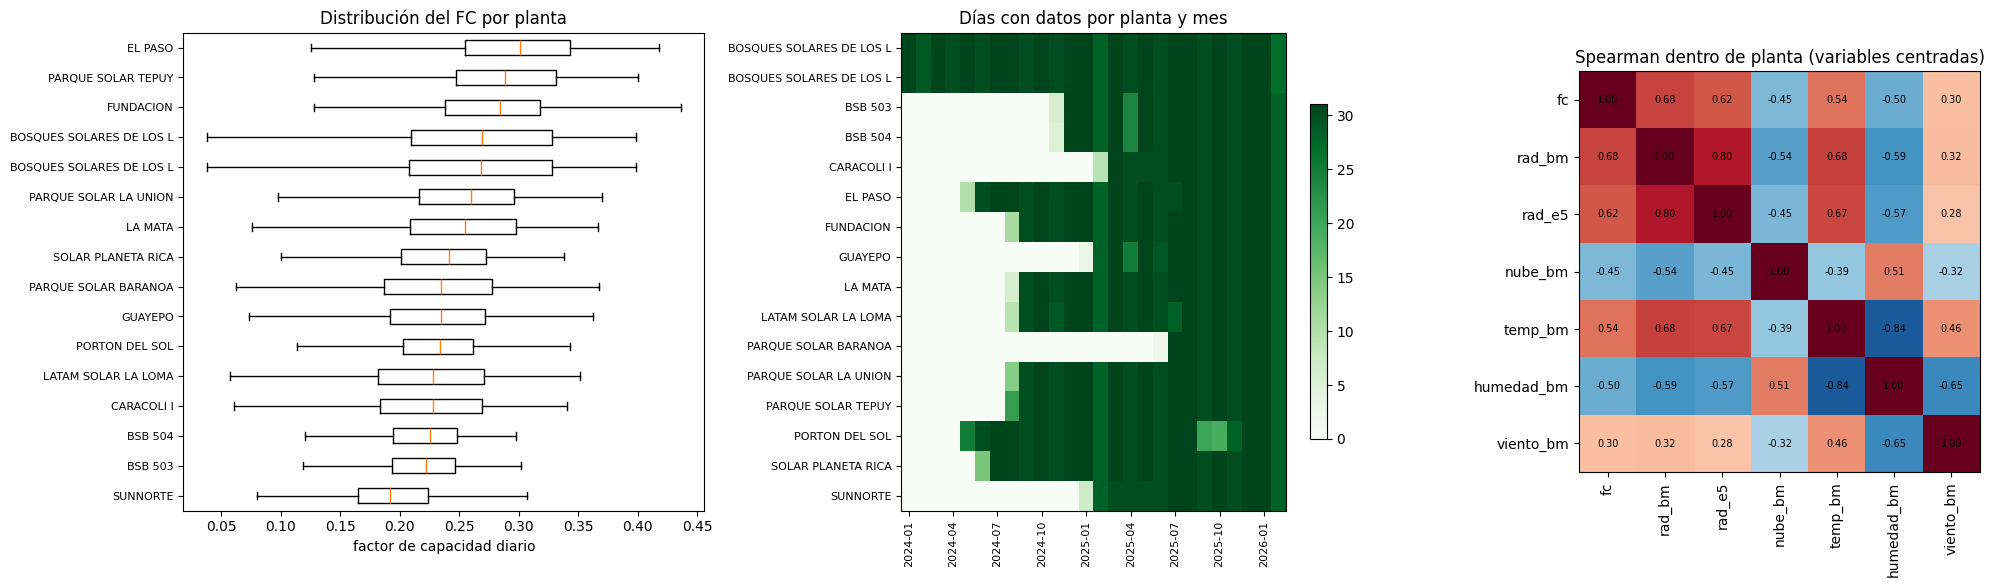

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6), gridspec_kw={"width_ratios": [1.3, 1.2, 1]})

orden = tabla.groupby("planta").fc.median().sort_values().index
axes[0].boxplot([tabla.loc[tabla.planta == p, "fc"] for p in orden], vert=False, showfliers=False)
axes[0].set_yticks(range(1, len(orden) + 1)); axes[0].set_yticklabels([p[:24] for p in orden], fontsize=8)
axes[0].set_xlabel("factor de capacidad diario"); axes[0].set_title("Distribución del FC por planta")

cob = (tabla.assign(mes=tabla.date.dt.to_period("M").astype(str)).groupby(["planta", "mes"]).size().unstack(fill_value=0))
im = axes[1].imshow(cob.values, aspect="auto", cmap="Greens", vmin=0, vmax=31)
axes[1].set_yticks(range(len(cob.index))); axes[1].set_yticklabels([p[:24] for p in cob.index], fontsize=8)
axes[1].set_xticks(range(0, len(cob.columns), 3)); axes[1].set_xticklabels(cob.columns[::3], rotation=90, fontsize=8)
axes[1].set_title("Días con datos por planta y mes"); fig.colorbar(im, ax=axes[1], shrink=.7)

VARS_CORR = ["fc", "rad_bm", "rad_e5", "nube_bm", "temp_bm", "humedad_bm", "viento_bm"]
cen = tabla[VARS_CORR + ["code"]].copy()
for v in VARS_CORR:
    cen[v] = cen[v] - cen.groupby("code")[v].transform("mean")
cor = cen[VARS_CORR].corr(method="spearman")
im2 = axes[2].imshow(cor.values, cmap="RdBu_r", vmin=-1, vmax=1)
axes[2].set_xticks(range(len(VARS_CORR))); axes[2].set_xticklabels(VARS_CORR, rotation=90)
axes[2].set_yticks(range(len(VARS_CORR))); axes[2].set_yticklabels(VARS_CORR)
for i in range(len(VARS_CORR)):
    for j in range(len(VARS_CORR)):
        axes[2].text(j, i, f"{cor.values[i, j]:.2f}", ha="center", va="center", fontsize=7)
axes[2].set_title("Spearman dentro de planta (variables centradas)")
fig.tight_layout(); fig.savefig("fig_eda_base_colombia.png", dpi=130, bbox_inches="tight"); plt.show()

La matriz de la derecha usa las variables con la media de cada planta restada, así que mide cómo se mueven juntas de un día a otro. La radiación
y la nubosidad están muy correlacionadas, igual que la temperatura y la humedad con la radiación. Eso explica por qué añadir esas variables a un modelo
que ya tiene la radiación aporta poco.

In [16]:
meta = plantas[plantas.code.isin(tabla.code.unique())][["code", "planta", "lat", "lon", "grupo"]].copy()
meta["fuente_coordenadas"] = meta.code.map(lambda c: "dataset del paper: " + EMPAREJAMIENTOS[c][0] if c in EMPAREJAMIENTOS else "ficha GEM: " + EXTRAS[c]["fuente"])
meta["precision"] = meta.code.map(lambda c: EXTRAS[c]["precision"] if c in EXTRAS else "la del dataset (GEM)")
meta["motivo"] = meta.code.map(lambda c: EMPAREJAMIENTOS[c][1] if c in EMPAREJAMIENTOS else EXTRAS[c]["motivo"])
# Lo poco que se sabe de tecnología, con su fuente. Todo lo demás queda pendiente.
DC_CONOCIDO = {
    "3EFY": ("27.39", "https://www.pv-magazine-latam.com/2022/07/15/inauguran-en-colombia-las-fases-4-y-5-de-bosques-de-los-llanos-complejo-solar-que-completa-125-mwp/"),
    "3EDL": ("25.01", "https://www.pv-magazine-latam.com/2022/07/15/inauguran-en-colombia-las-fases-4-y-5-de-bosques-de-los-llanos-complejo-solar-que-completa-125-mwp/"),
    "3IQA": ("41", "https://www.ecoener.es/proyectos/planta-fotovoltaica-sunnorte"),
}
meta["dc_MWp"] = meta.code.map(lambda c: DC_CONOCIDO.get(c, ("pendiente", ""))[0])
meta["fuente_dc"] = meta.code.map(lambda c: DC_CONOCIDO.get(c, ("", ""))[1])
meta["montaje"] = "pendiente"
meta = meta.merge(tabla.groupby("code").agg(dias=("fc", "size"), fc_medio=("fc", "mean"), cap_MW=("cap_MW", "median")).reset_index(), on="code")
meta.to_csv("plantas_colombia.csv", index=False)
meta[["code", "planta", "lat", "lon", "grupo", "dias", "fc_medio", "cap_MW", "precision"]].round(3)

,code,planta,lat,lon,grupo,dias,fc_medio,cap_MW,precision
0,3DDT,LATAM SOLAR LA LOMA,9.706,-73.522,5,551,0.223,150.0,la del dataset (GEM)
1,3HF5,FUNDACION,10.463,-74.616,6,557,0.275,100.0,la del dataset (GEM)
2,3INX,CARACOLI I,10.641,-75.002,6,373,0.223,50.0,la del dataset (GEM)
3,3J2B,SOLAR PLANETA RICA,8.442,-75.603,3,623,0.232,19.9,la del dataset (GEM)
4,4RGG,PARQUE SOLAR BARANOA,10.793,-74.915,6,245,0.231,19.9,la del dataset (GEM)
5,EPFV,EL PASO,9.781,-73.720,5,647,0.293,68.0,la del dataset (GEM)
6,GYPO,GUAYEPO,10.605,-74.783,6,390,0.231,370.0,la del dataset (GEM)
7,MATA,LA MATA,8.586,-73.613,4,552,0.250,80.0,la del dataset (GEM)
8,TPUY,PARQUE SOLAR TEPUY,5.469,-74.671,1,567,0.283,83.0,la del dataset (GEM)
9,3EFY,BOSQUES SOLARES DE LOS LLANOS 4,4.215,-72.027,2,789,0.262,19.9,aproximada (GEM)


### Tecnología de cada planta: pendiente

La tabla siguiente muestra lo que falta. Ninguna planta tiene confirmado el tipo de montaje (seguidor de un eje o estructura fija). Solo tres tienen una potencia
pico DC citada por una fuente, que reportó un investigador y no se revisó a mano. Mientras esto no se complete, la diferencia de nivel entre plantas
(el 16 % de la varianza del FC) queda sin explicar.

In [17]:
tec = meta[["code", "planta", "cap_MW", "dc_MWp", "montaje", "fuente_dc"]].copy()
tec["dc_ac"] = pd.to_numeric(tec.dc_MWp, errors="coerce") / tec.cap_MW
print("Plantas sin montaje confirmado:", int((tec.montaje == "pendiente").sum()), "de", len(tec))
print("Plantas sin potencia DC:", int((tec.dc_MWp == "pendiente").sum()), "de", len(tec))
tec.round(2)

Plantas sin montaje confirmado: 16 de 16
Plantas sin potencia DC: 13 de 16


,code,planta,cap_MW,dc_MWp,montaje,fuente_dc,dc_ac
0,3DDT,LATAM SOLAR LA LOMA,150.0,pendiente,pendiente,,NaN
1,3HF5,FUNDACION,100.0,pendiente,pendiente,,NaN
2,3INX,CARACOLI I,50.0,pendiente,pendiente,,NaN
3,3J2B,SOLAR PLANETA RICA,19.9,pendiente,pendiente,,NaN
4,4RGG,PARQUE SOLAR BARANOA,19.9,pendiente,pendiente,,NaN
5,EPFV,EL PASO,68.0,pendiente,pendiente,,NaN
6,GYPO,GUAYEPO,370.0,pendiente,pendiente,,NaN
7,MATA,LA MATA,80.0,pendiente,pendiente,,NaN
8,TPUY,PARQUE SOLAR TEPUY,83.0,pendiente,pendiente,,NaN
9,3EFY,BOSQUES SOLARES DE LOS LLANOS 4,19.9,27.39,pendiente,https://www.pv-magazine-latam.com/2022/07/15/inauguran-en-colombia-las-fases-4-y-5-de-bosques-de-los-llanos-complejo-solar-que-completa-125-mwp/,1.38


## 7. Qué se ve antes de modelar

Una gráfica por planta del FC contra la radiación del día, coloreada por nubosidad. Si el clima explica la generación, los puntos suben con la radiación.

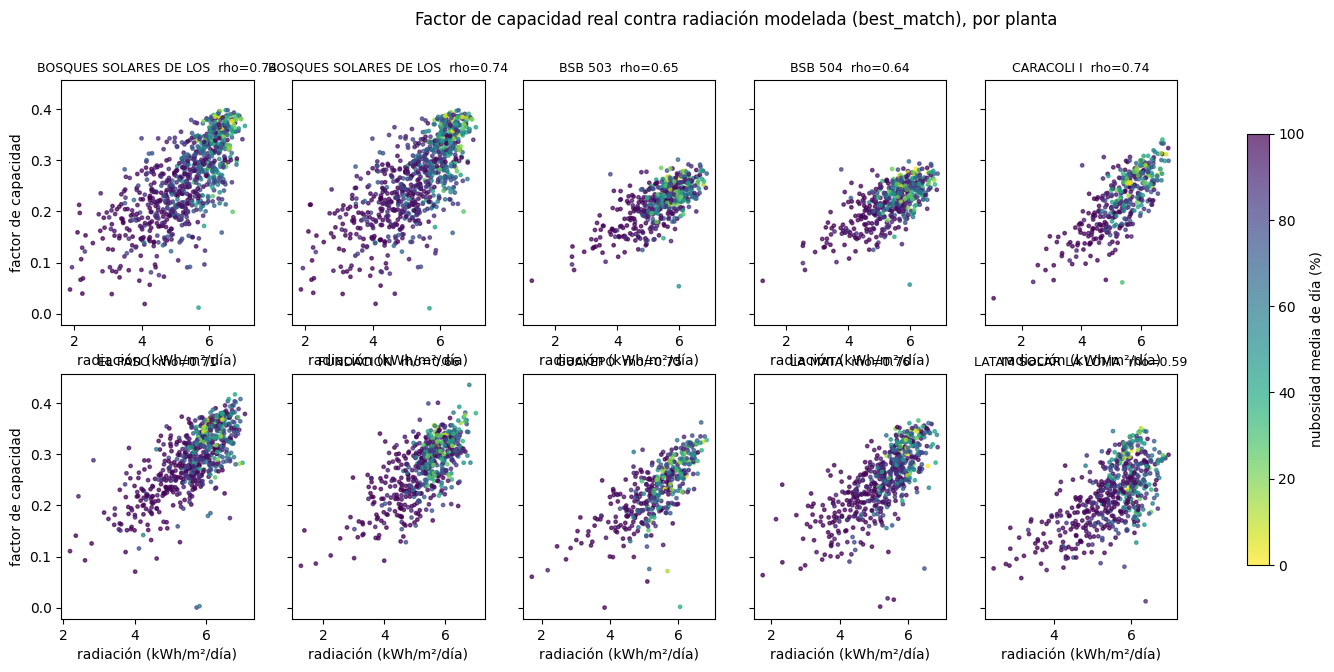

,rad_bm,nube_bm,temp_bm,humedad_bm,viento_bm
planta,,,,,
BOSQUES SOLARES DE LOS LLANOS 4,0.74,-0.54,0.65,-0.65,0.41
BOSQUES SOLARES DE LOS LLANOS 5,0.74,-0.54,0.64,-0.64,0.40
BSB 503,0.65,-0.45,0.54,-0.51,0.33
BSB 504,0.64,-0.47,0.53,-0.53,0.34
CARACOLI I,0.74,-0.52,0.59,-0.56,0.43
EL PASO,0.71,-0.50,0.56,-0.52,0.40
FUNDACION,0.66,-0.47,0.40,-0.33,0.06
GUAYEPO,0.75,-0.42,0.51,-0.47,0.23
LA MATA,0.76,-0.47,0.63,-0.60,0.47


In [18]:
fig, axes = plt.subplots(2, 5, figsize=(18, 7), sharey=True)
for ax, (nombre, g) in zip(axes.ravel(), tabla.groupby("planta")):
    sc = ax.scatter(g.rad_bm, g.fc, c=g.nube_bm, s=6, cmap="viridis_r", alpha=.7)
    ax.set_title(f"{nombre[:22]}  rho={spearmanr(g.rad_bm, g.fc)[0]:.2f}", fontsize=9)
    ax.set_xlabel("radiación (kWh/m²/día)")
axes[0, 0].set_ylabel("factor de capacidad"); axes[1, 0].set_ylabel("factor de capacidad")
fig.colorbar(sc, ax=axes, label="nubosidad media de día (%)", shrink=.8)
fig.suptitle("Factor de capacidad real contra radiación modelada (best_match), por planta", y=.98)
fig.savefig("fig_fc_vs_radiacion.png", dpi=130, bbox_inches="tight")
plt.show()

cols = ["rad_bm", "nube_bm", "temp_bm", "humedad_bm", "viento_bm"]
(tabla.groupby("planta").apply(lambda g: pd.Series({v: spearmanr(g[v], g.fc)[0] for v in cols})).round(2))

La temperatura sale con correlación positiva con el FC en todas las plantas. Físicamente el calor reduce el rendimiento, así que esa
correlación viene de que los días soleados también son más cálidos. No se debe leer como un efecto de la temperatura.

## 8. Cómo se evalúa

Cada planta tiene su propio nivel de FC por factores que no medimos (seguidores, relación DC/AC, edad). La varianza entre plantas se calcula al empezar la sección 9.1.
Para medir solo lo que el clima puede explicar, a cada variable se le resta la media de su planta y se predice el sube y baja diario, lo que presupone conocer el nivel de la planta.
En la evaluación temporal el nivel se calcula solo con la primera mitad de los días de cada planta.

Varias plantas están a menos de 100 km y comparten clima el mismo día, así que no se pueden tratar como independientes. La validación deja fuera un grupo
completo de plantas cercanas a la vez (`LeaveOneGroupOut` sobre `grupo`, es decir, leave-one-group-out) y no una planta suelta.

Con 16 plantas en 6 zonas, la unidad de muestreo es la planta: los intervalos salen de remuestrear plantas (Field y Welsh, 2007) y no filas.
Las comparaciones entre modelos usan diferencias pareadas por planta con la prueba de Wilcoxon. Con 16 pares la prueba tiene poca potencia, así que todo es exploratorio.

Las métricas son el R² dentro de la planta, el error absoluto medio relativo al FC medio de esa planta (MAE relativo) y la mejora frente a dos referencias sin clima:
predecir siempre el nivel de la planta y repetir el FC del día anterior.

In [19]:
FEATS = {
    "A. radiación era5":                        ["rad_e5"],
    "B. radiación best_match":                  ["rad_bm"],
    "C. física: radiación con temperatura":     ["e_fis_bm"],
    "D. plano con tilt=nan (modo seguidor de Open-Meteo)": ["gtitrk"],
    "E. radiación en plano fijo de 10°":        ["gti10"],
    "F. radiación + nubosidad":                 ["rad_bm", "nube_bm"],
    "G. todas (rad, nube, temp, humedad, viento)": ["rad_bm", "nube_bm", "temp_bm", "humedad_bm", "viento_bm"],
    "H. solo nubosidad":                        ["nube_bm"],
}

def centrar(df, cols):
    c = df.copy()
    for v in cols:
        c[v + "_c"] = c[v] - c.groupby("code")[v].transform("mean")
    return c

def metricas_planta(y_real, y_pred, y_media, y_ayer):
    sst = ((y_real - y_real.mean()) ** 2).sum()
    mae = np.abs(y_real - y_pred).mean()
    mae_nivel = np.abs(y_real - y_media).mean()
    ok = ~np.isnan(y_ayer)
    mae_pers = np.abs(y_real[ok] - y_ayer[ok]).mean() if ok.sum() > 5 else np.nan
    return {"r2": 1 - ((y_real - y_pred) ** 2).sum() / sst, "mae_rel": mae / y_media,
            "mejora_vs_nivel": 1 - mae / mae_nivel,
            "mejora_vs_persistencia": 1 - np.abs(y_real[ok] - y_pred[ok]).mean() / mae_pers if ok.sum() > 5 else np.nan}

def evalua_nivel_conocido(df, feats, modelo=LinearRegression):
    cols = feats + ["fc"]
    c = centrar(df, cols)
    filas = []
    for tr, te in LeaveOneGroupOut().split(c, groups=c.grupo):
        m = modelo().fit(c.iloc[tr][[v + "_c" for v in feats]], c.iloc[tr].fc_c)
        d = c.iloc[te].copy()
        d["pred_c"] = m.predict(d[[v + "_c" for v in feats]])
        for code, g in d.groupby("code"):
            media = df[df.code == code].fc.mean()
            y = g.fc.values; pred = g.pred_c.values + media
            filas.append({"code": code, "planta": g.planta.iloc[0], "n": len(g),
                          **metricas_planta(y, pred, media, g.fc_ayer.values)})
    return pd.DataFrame(filas)

def evalua_temporal(df, feats, modelo=LinearRegression):
    d = df.copy()
    d["mitad"] = d.groupby("code").cumcount() >= d.groupby("code").fc.transform("size") // 2
    ent, prueba = d[~d.mitad], d[d.mitad]
    medias = ent.groupby("code")[feats + ["fc"]].mean()
    ent_c = ent.copy(); prueba_c = prueba.copy()
    for v in feats + ["fc"]:
        ent_c[v + "_c"] = ent[v] - ent.code.map(medias[v]); prueba_c[v + "_c"] = prueba[v] - prueba.code.map(medias[v])
    filas = []
    for g_id in d.grupo.unique():
        tr, te = ent_c[ent_c.grupo != g_id], prueba_c[prueba_c.grupo == g_id]
        m = modelo().fit(tr[[v + "_c" for v in feats]], tr.fc_c)
        for code, g in te.groupby("code"):
            media = medias.loc[code, "fc"]
            pred = m.predict(g[[v + "_c" for v in feats]]) + media
            filas.append({"code": code, "planta": g.planta.iloc[0], "n": len(g), **metricas_planta(g.fc.values, pred, media, g.fc_ayer.values)})
    return pd.DataFrame(filas)

def ic_bootstrap(valores, B=5000):
    v = np.asarray(valores); n = len(v)
    med = [np.median(v[RNG.integers(0, n, n)]) for _ in range(B)]
    return np.percentile(med, [2.5, 97.5])

def tabla_resumen(funcion, conjuntos=FEATS, df=None):
    df = tabla if df is None else df
    filas, por_planta = [], {}
    for nombre, feats in conjuntos.items():
        r = funcion(df, feats)
        por_planta[nombre] = r.set_index("code")
        lo, hi = ic_bootstrap(r.r2)
        filas.append({"variables": nombre, "r2_mediana": r.r2.median(), "ic95_bajo": lo, "ic95_alto": hi,
                      "r2_min": r.r2.min(), "r2_max": r.r2.max(), "mae_rel_medio": r.mae_rel.mean(),
                      "mejora_vs_nivel": r.mejora_vs_nivel.mean(), "mejora_vs_persistencia": r.mejora_vs_persistencia.mean()})
    return pd.DataFrame(filas).set_index("variables"), por_planta

## 9. Resultados

### 9.1 Nivel de la planta conocido

El nivel de cada planta se calcula con todos sus días, y la validación deja fuera un grupo completo de plantas cercanas.

In [20]:
w = tabla.groupby("code").fc.transform(lambda s: s - s.mean()).var()
print(f"Varianza del FC entre plantas: {100 * (1 - w / tabla.fc.var()):.0f} %  |  dentro de cada planta, día a día: {100 * w / tabla.fc.var():.0f} %")

COLS_1 = ["r2_mediana", "ic95_bajo", "ic95_alto", "r2_min", "r2_max"]
COLS_2 = ["mae_rel_medio", "mejora_vs_nivel", "mejora_vs_persistencia"]
res_A, pp_A = tabla_resumen(evalua_nivel_conocido)
display(res_A[COLS_1].round(3)); display(res_A[COLS_2].round(3))

Varianza del FC entre plantas: 16 %  |  dentro de cada planta, día a día: 84 %


,r2_mediana,ic95_bajo,ic95_alto,r2_min,r2_max
variables,,,,,
A. radiación era5,0.414,0.336,0.446,0.005,0.542
B. radiación best_match,0.493,0.375,0.508,0.090,0.592
C. física: radiación con temperatura,0.487,0.367,0.499,0.060,0.585
D. plano con tilt=nan (modo seguidor de Open-Meteo),0.260,0.196,0.293,0.023,0.386
E. radiación en plano fijo de 10°,0.468,0.407,0.518,0.100,0.589
F. radiación + nubosidad,0.495,0.365,0.517,0.102,0.599
"G. todas (rad, nube, temp, humedad, viento)",0.491,0.396,0.528,0.109,0.624
H. solo nubosidad,0.168,0.109,0.193,-0.059,0.219


,mae_rel_medio,mejora_vs_nivel,mejora_vs_persistencia
variables,,,
A. radiación era5,0.148,0.228,0.264
B. radiación best_match,0.139,0.276,0.309
C. física: radiación con temperatura,0.140,0.271,0.304
D. plano con tilt=nan (modo seguidor de Open-Meteo),0.165,0.142,0.177
E. radiación en plano fijo de 10°,0.138,0.282,0.313
F. radiación + nubosidad,0.137,0.284,0.316
"G. todas (rad, nube, temp, humedad, viento)",0.135,0.293,0.325
H. solo nubosidad,0.177,0.081,0.117


In [21]:
c = centrar(tabla, ["rad_bm", "fc"])
pend = np.polyfit(c.rad_bm_c, c.fc_c, 1)[0]
print(f"Pendiente dentro de planta: {100 * pend:.1f} puntos de FC por cada kWh/m² de radiación diaria")
print(f"Proporcionalidad simple: FC medio / radiación media = {100 * tabla.fc.mean() / tabla.rad_bm.mean():.1f} puntos por kWh/m²")
print(f"Plantas: {tabla.code.nunique()} | grupos de cercanía: {tabla.grupo.nunique()} | filas: {len(tabla)} | del {tabla.date.min().date()} al {tabla.date.max().date()}")

Pendiente dentro de planta: 4.7 puntos de FC por cada kWh/m² de radiación diaria
Proporcionalidad simple: FC medio / radiación media = 4.6 puntos por kWh/m²
Plantas: 16 | grupos de cercanía: 6 | filas: 8589 | del 2024-01-01 al 2026-02-28


In [22]:
base = "B. radiación best_match"
filas = []
for nombre, r in pp_A.items():
    if nombre == base:
        continue
    d = (r.r2 - pp_A[base].r2).dropna()
    p = wilcoxon(d).pvalue if (d != 0).any() else np.nan
    filas.append({"modelo": nombre, "dif_r2_media_vs_B": d.mean(), "dif_min": d.min(), "dif_max": d.max(), "p_wilcoxon": p})
pd.DataFrame(filas).set_index("modelo").round(3)

,dif_r2_media_vs_B,dif_min,dif_max,p_wilcoxon
modelo,,,,
A. radiación era5,-0.065,-0.290,0.108,0.065
C. física: radiación con temperatura,-0.007,-0.030,0.009,0.002
D. plano con tilt=nan (modo seguidor de Open-Meteo),-0.189,-0.371,-0.067,0.000
E. radiación en plano fijo de 10°,0.005,-0.069,0.065,0.562
F. radiación + nubosidad,0.007,-0.030,0.033,0.175
"G. todas (rad, nube, temp, humedad, viento)",0.018,-0.012,0.036,0.001
H. solo nubosidad,-0.300,-0.446,-0.014,0.000


Los valores p son crudos, de una prueba con 16 pares y 7 comparaciones. No se corrigen por comparaciones múltiples porque no hay una hipótesis confirmatoria: se leen como orden de magnitud de la diferencia.

### 9.2 Nivel estimado con el pasado

Aquí el nivel de cada planta sale solo de la primera mitad de sus días, y se evalúa en la segunda mitad. Es una prueba más dura: las plantas cuyo nivel se desplaza en el tiempo salen peor.

In [23]:
res_B, pp_B = tabla_resumen(evalua_temporal)
display(res_B[COLS_1].round(3)); display(res_B[COLS_2].round(3))

,r2_mediana,ic95_bajo,ic95_alto,r2_min,r2_max
variables,,,,,
A. radiación era5,0.424,0.271,0.435,-0.588,0.492
B. radiación best_match,0.495,0.366,0.517,-0.420,0.584
C. física: radiación con temperatura,0.492,0.356,0.505,-0.421,0.578
D. plano con tilt=nan (modo seguidor de Open-Meteo),0.083,0.021,0.197,-0.646,0.400
E. radiación en plano fijo de 10°,0.427,0.320,0.516,-0.382,0.578
F. radiación + nubosidad,0.465,0.340,0.522,-0.460,0.602
"G. todas (rad, nube, temp, humedad, viento)",0.466,0.344,0.546,-0.469,0.619
H. solo nubosidad,0.090,0.011,0.126,-0.950,0.185


,mae_rel_medio,mejora_vs_nivel,mejora_vs_persistencia
variables,,,
A. radiación era5,0.153,0.211,0.250
B. radiación best_match,0.141,0.269,0.305
C. física: radiación con temperatura,0.142,0.264,0.301
D. plano con tilt=nan (modo seguidor de Open-Meteo),0.181,0.049,0.095
E. radiación en plano fijo de 10°,0.142,0.264,0.301
F. radiación + nubosidad,0.141,0.271,0.306
"G. todas (rad, nube, temp, humedad, viento)",0.140,0.276,0.311
H. solo nubosidad,0.185,0.039,0.085


In [24]:
pd.DataFrame({"r2 nivel conocido (B)": pp_A[base].r2, "r2 temporal (B)": pp_B[base].r2,
              "r2 nivel conocido (C física)": pp_A["C. física: radiación con temperatura"].r2,
              "r2 temporal (C física)": pp_B["C. física: radiación con temperatura"].r2}
             ).join(tabla.groupby("code").planta.first()).set_index("planta").round(2)

,r2 nivel conocido (B),r2 temporal (B),r2 nivel conocido (C física),r2 temporal (C física)
planta,,,,
LATAM SOLAR LA LOMA,0.40,-0.42,0.39,-0.42
BOSQUES SOLARES DE LOS LLANOS 5,0.50,0.50,0.49,0.49
BOSQUES SOLARES DE LOS LLANOS 4,0.50,0.51,0.50,0.50
FUNDACION,0.49,0.53,0.49,0.52
CARACOLI I,0.59,0.52,0.59,0.51
SUNNORTE,0.09,0.01,0.06,-0.02
PORTON DEL SOL,0.30,0.32,0.30,0.32
PARQUE SOLAR LA UNION,0.51,0.58,0.51,0.58
SOLAR PLANETA RICA,0.35,0.32,0.35,0.31


### 9.3 Un modelo flexible

Para comprobar si un modelo no lineal cambia algo, se prueba HistGradientBoosting (Friedman, 2001) con todas las variables centradas, con la misma validación por grupos.
Sin ajuste de hiperparámetros y con 16 plantas, una pérdida frente al modelo lineal puede venir del sobreajuste del propio modelo y no del clima.

In [25]:
r_hgb = evalua_nivel_conocido(tabla, FEATS["G. todas (rad, nube, temp, humedad, viento)"],
                              modelo=lambda: HistGradientBoostingRegressor(random_state=SEED))
lo, hi = ic_bootstrap(r_hgb.r2)
print(f"HGB, todas las variables centradas: R² mediana {r_hgb.r2.median():.3f}  (IC95 {lo:.3f} a {hi:.3f})")
print(f"Lineal, mismas variables:           R² mediana {res_A.loc['G. todas (rad, nube, temp, humedad, viento)', 'r2_mediana']:.3f}")

HGB, todas las variables centradas: R² mediana 0.450  (IC95 0.289 a 0.514)
Lineal, mismas variables:           R² mediana 0.491


### 9.4 Sensibilidad a decisiones previas

Cada fila cambia una decisión y repite la evaluación con solo radiación (B) y con la física (C).

In [26]:
def sens(df, etiqueta):
    cj = {k: FEATS[k] for k in ["B. radiación best_match", "C. física: radiación con temperatura"]}
    r, _ = tabla_resumen(evalua_nivel_conocido, cj, df)
    return r[["r2_mediana", "ic95_bajo", "ic95_alto"]].assign(escenario=etiqueta, n_filas=len(df)).reset_index()

esc = [
    sens(tabla, "principal (60 días de arranque excluidos)"),
    sens(completa[completa.code.isin(validas)], "sin excluir días de arranque"),
    sens(completa[completa.code.isin(validas) & (completa.dias_desde_arranque >= 90)], "90 días de arranque excluidos"),
    sens(tabla_base, "incluyendo ALMA II (8 días útiles)"),
    sens(tabla[tabla.fc >= 0.02], "sin días con FC < 0.02 (filtra por la respuesta, solo sensibilidad)"),
]
pd.concat(esc).set_index(["escenario", "variables"]).round(3)

r2_mediana  \
escenario                                                           variables                                          
principal (60 días de arranque excluidos)                           B. radiación best_match                    0.493   
                                                                    C. física: radiación con temperatura       0.487   
sin excluir días de arranque                                        B. radiación best_match                    0.486   
                                                                    C. física: radiación con temperatura       0.478   
90 días de arranque excluidos                                       B. radiación best_match                    0.502   
                                                                    C. física: radiación con temperatura       0.491   
incluyendo ALMA II (8 días útiles)                                  B. radiación best_match                    0.487   
                                                                    C. física: radiación con temperatura       0.487   
sin días con FC < 0.02 (filtra por la respuesta, solo sensibilidad) B. radiación best_match                    0.498   
                                                                    C. física: radiación con temperatura       0.494   

                                                                                                          ic95_bajo  \
escenario                                                           variables                                         
principal (60 días de arranque excluidos)                           B. radiación best_match                   0.375   
                                                                    C. física: radiación con temperatura      0.370   
sin excluir días de arranque                                        B. radiación best_match                   0.357   
                                                                    C. física: radiación con temperatura      0.353   
90 días de arranque excluidos                                       B. radiación best_match                   0.393   
                                                                    C. física: radiación con temperatura      0.388   
incluyendo ALMA II (8 días útiles)                                  B. radiación best_match                   0.355   
                                                                    C. física: radiación con temperatura      0.350   
sin días con FC < 0.02 (filtra por la respuesta, solo sensibilidad) B. radiación best_match                   0.377   
                                                                    C. física: radiación con temperatura      0.371   

                                                                                                          ic95_alto  \
escenario                                                           variables                                         
principal (60 días de arranque excluidos)                           B. radiación best_match                   0.504   
                                                                    C. física: radiación con temperatura      0.497   
sin excluir días de arranque                                        B. radiación best_match                   0.503   
                                                                    C. física: radiación con temperatura      0.495   
90 días de arranque excluidos                                       B. radiación best_match                   0.512   
                                                                    C. física: radiación con temperatura      0.508   
incluyendo ALMA II (8 días útiles)                                  B. radiación best_match                   0.504   
                                                                    C. física: radiación con temperatura      0.496   
sin días con FC < 0.02 (filtra por la respuest

### 9.5 Cuánto pesa la fuente de radiación

Los modelos A y B usan la misma regresión sobre la radiación de dos productos de Open-Meteo. Si la diferencia entre ellos es grande, la calidad del modelo de clima
es parte del techo del resultado.

In [27]:
pd.DataFrame({"era5 (0.25°)": pp_A["A. radiación era5"].r2, "best_match": pp_A["B. radiación best_match"].r2}
            ).join(tabla.groupby("code").planta.first()).set_index("planta").round(2)

,era5 (0.25°),best_match
planta,,
PORTON DEL SOL,0.01,0.30
PARQUE SOLAR TEPUY,0.22,0.41
BOSQUES SOLARES DE LOS LLANOS 5,0.42,0.50
BOSQUES SOLARES DE LOS LLANOS 4,0.42,0.50
PARQUE SOLAR LA UNION,0.41,0.51
SOLAR PLANETA RICA,0.29,0.35
SUNNORTE,0.20,0.09
LA MATA,0.41,0.50
LATAM SOLAR LA LOMA,0.34,0.40


### 9.6 Modelos del curso, versión preliminar

Prueba de los modelos base que pide el curso sobre esta base: regresión lineal, Ridge, Lasso, KNN y SVR con kernel RBF, más HistGradientBoosting
como modelo flexible y la referencia de predecir el nivel de la planta.

Cómo se evita la fuga de información:
- La partición va primero. La validación deja fuera una zona completa de plantas cercanas (`LeaveOneGroupOut` sobre `grupo`).
- El nivel de cada planta se calcula solo con la primera mitad de sus días (el pasado) y se evalúa en la segunda mitad. Las plantas de la zona de prueba no entran al entrenamiento.
- El escalado (`StandardScaler`) va dentro de un `Pipeline`, así que se ajusta solo con los datos de entrenamiento de cada partición.
- Los hiperparámetros quedan fijos en valores por defecto razonables. No se ajustan aquí, porque ajustarlos con los mismos datos de prueba inflaría el resultado. El ajuste con validación anidada por grupos se hace en `Benchmark_Colombia.ipynb`.

Variables: radiación, nubosidad, temperatura, humedad y viento (`best_match`).

In [28]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

class NivelPlanta:
    # Predice desviación 0: el FC es el nivel de la planta calculado con el pasado
    def fit(self, X, y): return self
    def predict(self, X): return np.zeros(len(X))

MODELOS_CURSO = {
    "nivel de la planta (referencia)": lambda: NivelPlanta(),
    "regresión lineal": lambda: make_pipeline(StandardScaler(), LinearRegression()),
    "Ridge (alpha=1)": lambda: make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "Lasso (alpha=0.001)": lambda: make_pipeline(StandardScaler(), Lasso(alpha=0.001, max_iter=10000)),
    "KNN (k=25)": lambda: make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=25)),
    "SVR RBF (C=1, epsilon=0.01)": lambda: make_pipeline(StandardScaler(), SVR(C=1.0, epsilon=0.01)),
    "HistGradientBoosting": lambda: HistGradientBoostingRegressor(random_state=SEED),
}
VARS_G = FEATS["G. todas (rad, nube, temp, humedad, viento)"]
filas, por_planta_curso = [], {}
for nombre, fab in MODELOS_CURSO.items():
    t0 = time.time()
    r = evalua_temporal(tabla, VARS_G, modelo=fab)
    por_planta_curso[nombre] = r.set_index("code").r2
    lo, hi = ic_bootstrap(r.r2)
    filas.append({"modelo": nombre, "r2_mediana": r.r2.median(), "ic95_bajo": lo, "ic95_alto": hi,
                  "mae_rel_medio": r.mae_rel.mean(), "mejora_vs_persistencia": r.mejora_vs_persistencia.mean(),
                  "segundos": time.time() - t0})
res_curso = pd.DataFrame(filas).set_index("modelo")
res_curso.round(3)

,r2_mediana,ic95_bajo,ic95_alto,mae_rel_medio,mejora_vs_persistencia,segundos
modelo,,,,,,
nivel de la planta (referencia),-0.039,-0.058,-0.014,0.193,0.050,0.094
regresión lineal,0.466,0.344,0.546,0.140,0.311,0.143
Ridge (alpha=1),0.466,0.347,0.546,0.140,0.311,0.217
Lasso (alpha=0.001),0.469,0.358,0.538,0.139,0.312,0.116
KNN (k=25),0.396,0.228,0.468,0.149,0.261,0.167
"SVR RBF (C=1, epsilon=0.01)",0.358,0.179,0.466,0.150,0.255,3.753
HistGradientBoosting,0.379,0.250,0.479,0.147,0.269,1.505


In [29]:
pd.DataFrame(por_planta_curso).join(tabla.groupby("code").planta.first()).set_index("planta").round(2)

,nivel de la planta (referencia),regresión lineal,Ridge (alpha=1),Lasso (alpha=0.001),KNN (k=25),"SVR RBF (C=1, epsilon=0.01)",HistGradientBoosting
planta,,,,,,,
LATAM SOLAR LA LOMA,-0.95,-0.47,-0.47,-0.46,-0.45,-0.37,-0.48
EL PASO,-0.00,0.52,0.52,0.52,0.42,0.43,0.46
BOSQUES SOLARES DE LOS LLANOS 5,-0.04,0.55,0.55,0.54,0.51,0.47,0.52
BOSQUES SOLARES DE LOS LLANOS 4,-0.04,0.55,0.55,0.55,0.52,0.48,0.53
FUNDACION,-0.03,0.51,0.51,0.51,0.46,0.47,0.41
CARACOLI I,-0.04,0.58,0.58,0.58,0.47,0.44,0.50
BSB 503,-0.06,0.35,0.35,0.37,0.22,0.00,0.22
BSB 504,-0.05,0.35,0.35,0.38,0.22,-0.01,0.23
PARQUE SOLAR BARANOA,-0.00,0.62,0.62,0.62,0.43,0.36,0.42


## 10. Del cuaderno de clima al benchmark

Las pruebas de la sección 9 son preliminares: hiperparámetros fijos y un solo esquema de validación. Los modelos base del curso, con ajuste de hiperparámetros por validación
anidada, se corren en `Benchmark_Colombia.ipynb`: regresión lineal, Ridge, Lasso, KNN y SVR con kernel RBF para el factor de capacidad, y la referencia de predecir el nivel de la planta.
Allí el nivel de cada planta se estima con el pasado, el escalado va dentro del `Pipeline` y la búsqueda de hiperparámetros tiene un bucle interno que también agrupa por zona.

HistGradientBoosting no pasó a ese benchmark, porque en las pruebas preliminares no superó al modelo lineal. Lo que más cambiaría los resultados serían los datos: la tecnología
de cada planta, datos horarios y radiación medida.

## 11. Conclusiones

Muestra: 16 plantas con coordenadas verificadas y al menos 100 días útiles, en 6 zonas de cercanía, del 1 de enero de 2024 al 28 de febrero de 2026, con 8,589 filas planta-día y sin valores vacíos en la tabla final. Nueve plantas salen del dataset del paper y siete de la ficha pública de GEM, cada una contrastada con prensa o con el desarrollador. ALMA II sale por quedar con 8 días útiles, Palmira II porque su ubicación no se confirmó, y Shangri-La porque sus coordenadas en GEM contradicen su propia ficha.

Con el nivel de cada planta conocido (sección 9.1):
- La radiación diaria de Open-Meteo (`best_match`) explica una mediana de R² de 0.49 de la variación día a día dentro de una planta (IC95 de 0.38 a 0.51 remuestreando plantas). Por planta va de 0.09 (Sunnorte, en Ocaña) a 0.59 (Caracolí). Esa variación diaria es el 84 % de la varianza total del FC.
- Cada kWh/m² adicional de radiación diaria suma unos 4.7 puntos de factor de capacidad, casi lo mismo que sale de dividir el FC medio entre la radiación media (4.6). Coincide con lo que predice la física.
- Frente a predecir el nivel de la planta, el error absoluto baja un 28 %. Frente a repetir el FC de ayer, baja un 31 %.
- La pérdida por temperatura de celda (0.4 % por °C, NOCT de 45 °C) no mejora la radiación sola (0.487 frente a 0.493), y sus parámetros son genéricos.
- Añadir nubosidad, temperatura, humedad y viento sube el R² por planta en promedio 0.018 (de -0.012 a +0.036). La nubosidad sola explica 0.17.
- La fuente de radiación pesa: con `era5` la mediana es 0.41 y con `best_match` 0.49. `best_match` gana en 13 de las 16 plantas.

Con el nivel calculado con el pasado y el escalado dentro de cada partición (sección 9.6), regresión lineal, Ridge y Lasso dan una mediana de 0.47. KNN da 0.40, SVR 0.36 y HistGradientBoosting 0.38, así que los modelos flexibles no superan al lineal con 16 plantas y 6 zonas. La planta La Loma sale negativa en esta prueba (-0.47) porque su nivel se desplazó entre la primera y la segunda mitad del período. No verificamos la causa. En la sensibilidad (sección 9.4), la mediana va de 0.486 a 0.502 al cambiar la exclusión del arranque o incluir ALMA II.

Hay cosas que estos resultados no permiten afirmar. No muestran que la nubosidad explique algo además de la radiación, porque la radiación del modelo ya integra sus propias nubes y la nubosidad diaria no capta cuánto cambia el cielo durante el día. Tampoco muestran que 0.5 sea el techo, ya que cambiar de producto de radiación movió la mediana de 0.41 a 0.49 y la tecnología de cada planta no está medida. Y no se puede extender a cualquier zona: hay 6, cinco en el norte y el centro del país y una en los Llanos, y Sunnorte, en zona de montaña, sale mucho peor que el resto.

El ajuste de hiperparámetros con validación anidada por zonas está en `Benchmark_Colombia.ipynb`. Queda pendiente:
1. La tecnología de cada planta (seguidor o fija, potencia DC frente a AC). Ninguna de las 16 tiene el montaje confirmado y solo 3 tienen la potencia DC con fuente.
2. Comparar la radiación modelada con radiación medida (estaciones del IDEAM) o satelital.
3. Repetir con datos horarios y con un índice de claridad para la pregunta de las nubes.

## 12. Referencias

Los BibTeX están en `referencias.bib`. Las entradas sin DOI llevan la URL.

- Enel Green Power. (2023). *El parque solar Fundación, construido por Enel Green Power en el departamento del Magdalena, inicia su etapa de pruebas*. https://www.enelgreenpower.com/es/medios/press/2023/09/egp-colombia-inicio-etapa-de-pruebas-parque-solar-fundacion
- Field, C. A. y Welsh, A. H. (2007). Bootstrapping clustered data. *Journal of the Royal Statistical Society B*. https://doi.org/10.1111/j.1467-9868.2007.00593.x
- Friedman, J. H. (2001). Greedy function approximation: a gradient boosting machine. *The Annals of Statistics*. https://doi.org/10.1214/aos/1013203451
- Global Energy Monitor. (2026). *Global Solar Power Tracker, February 2026 release*. https://globalenergymonitor.org/projects/global-solar-power-tracker
- Hersbach, H. et al. (2020). The ERA5 global reanalysis. *Quarterly Journal of the Royal Meteorological Society, 146*(730), 1999-2049. https://doi.org/10.1002/qj.3803
- Mantilla-Guerra, A., Mejia-Escobar, C., Azorin-Lopez, J. y Garcia-Rodriguez, J. (2026). Global dataset of solar power plants: multidimensional integration and analysis. *Eng, 7*(7), 343. https://doi.org/10.3390/eng7070343 (preprint arXiv:2603.20601)
- Muñoz-Sabater, J. et al. (2021). ERA5-Land: a state-of-the-art global reanalysis dataset for land applications. *Earth System Science Data, 13*(9), 4349-4383. https://doi.org/10.5194/essd-13-4349-2021
- pv magazine LATAM. (2023, 15 de marzo). *Avanza en Colombia el parque solar Fundación, de 132 MW*. https://www.pv-magazine-latam.com/2023/03/15/avanza-en-colombia-el-parque-solar-fundacion-de-132-mw/
- Skoplaki, E. y Palyvos, J. A. (2009). On the temperature dependence of photovoltaic module electrical performance: a review of efficiency/power correlations. *Solar Energy, 83*(5), 614-624. https://doi.org/10.1016/j.solener.2008.10.008
- Skoplaki, E. y Palyvos, J. A. (2009). Operating temperature of photovoltaic modules: a survey of pertinent correlations. *Renewable Energy, 34*(1), 23-29. https://doi.org/10.1016/j.renene.2008.04.009
- XM S.A. E.S.P. (2026). *API pública de datos del mercado de energía mayorista y portal SiMEM*. https://www.simem.co/
- Zippenfenig, P. (2023). *Open-Meteo.com Weather API* [software]. Zenodo. https://doi.org/10.5281/zenodo.7970649